# Aprikose/Marille Recipe Clustering — MDS + All Algorithms

Applies the same pipeline as V18_1 to the **Aprikose/Marille trial set** (Second Trial Set PDM, 10-04-2026).  
No panelist free-sorting data is available yet. Clusters are generated purely from ingredient composition.

**Workflow:**
1. Load ingredient data from Excel (17 recipes)
2. Auto-detect the optimal number of clusters via Silhouette / DB / CH indices + Ward dendrogram
3. Build MDS maps for all 4 recipe-vector models (M1–M4)
4. Apply all 10 clustering algorithms at the auto-detected k
5. Cross-algorithm agreement matrix — compares algorithms pairwise (no free-sorting ground truth yet)
6. Recipe stability — which recipes are consistently assigned the same cluster across algorithms?

**When panelist free-sorting becomes available**, add a Section 7 replicating the V18_1 Hungarian alignment vs free sorting.

## Algorithm Reference

| Algorithm | Type | How it works (short) |
|---|---|---|
| **k-Means** | Centroid partition | Iteratively assigns each recipe to the nearest centroid and recomputes centroids until convergence. Minimises total within-cluster variance (Euclidean). k is fixed. |
| **k-Medoids (PAM)** | Medoid partition | Like k-Means but centres are actual data points (*medoids*). More robust to outliers; operates on any distance matrix — here the precomputed cosine distance. |
| **Ward Linkage** | Hierarchical | Builds a merge tree (dendrogram) by always joining the pair of clusters whose merger causes the smallest increase in total within-cluster variance. A cut at distance *t* gives *k* clusters. |
| **DBSCAN** | Density-based | Groups recipes within distance ε of at least `min_samples` neighbours into a cluster. Points that never reach that density threshold become *noise* (resolved here to the nearest cluster). *k* is data-driven. |
| **HDBSCAN** | Hierarchical density | Builds a full hierarchy of DBSCAN solutions across all ε values and extracts the most stable clusters. More robust than DBSCAN when cluster densities vary. |
| **GMM** | Probabilistic | Models data as a mixture of *k* multivariate Gaussians. Each recipe has a soft probability of belonging to each component; the hard label is the highest-probability component. |
| **Spectral Clustering** | Graph-based | Builds a similarity graph (cosine similarity as affinity), computes the Laplacian eigenvectors, then applies k-Means in that low-dimensional embedding. Finds non-convex clusters invisible to k-Means. |
| **Fuzzy c-Means** | Soft partition | Each recipe belongs to *all* k clusters simultaneously with a membership degree (degrees sum to 1). Minimises a weighted within-cluster distance; the fuzziness exponent *m* controls how soft the boundaries are. Hard labels are derived by argmax. |
| **SOM** | Topological map | Trains a 2-D node grid on the recipe vectors via competitive learning: the winning node and its neighbours update towards each input. Recipes are assigned to their closest node; node groups are mapped to *k* clusters via k-Means on the node weights. |
| **DEC (simplified)** | Deep / embedding | Encodes recipes into a compact space (PCA here; a neural autoencoder in the full method), initialises centres with k-Means, then iteratively sharpens soft assignments using a Student-*t* kernel and a KL-divergence target distribution (Xie et al., ICML 2016). |

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import MDS
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import openpyxl
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    from sklearn.cluster import HDBSCAN as _HDBSCAN
    _has_hdbscan = True
except ImportError:
    _has_hdbscan = False

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLUSTER_COLORS = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
    '#F4A261', '#A8DADC', '#6A0572', '#264653',
]

# ── Data paths ────────────────────────────────────────────────────────────────
EXCEL_PATH  = Path('../data/gold/Second_Trial_Set_PDM Aprikose_Marille 10-04-2026.xlsx')
IGNORE_PATH = Path('../data/gold/ignone_substances.csv')

# ── Aprikose column names (differ from Erdbeere/V18) ─────────────────────────
OT1           = 'Odour Type 1'
OT2           = 'Odour Type 2'
OT3           = 'Odour Type 3'
THRESHOLD_COL = 'Threshold ppm'
REZ_COL       = 'Rez.-Nr.'
IDENT_COL     = 'Ident'      # ingredient ident (col 7 in sheet)
CAS_COL       = 'CAS-Nr.'
NAME_COL      = 'Name'
TOTAL_COL     = 'Totalmenge'

print('Libraries loaded.')
print(f'HDBSCAN available: {_has_hdbscan}')


Libraries loaded.
HDBSCAN available: True


## 1. Load Aprikose Recipe Data

In [2]:
def to_float(v, fallback=0.0):
    """Parse European decimal strings ('1,3E-5') and native floats/ints."""
    if v is None: return fallback
    if isinstance(v, (int, float)): return float(v)
    try: return float(str(v).strip().replace(',', '.'))
    except: return fallback

wb = openpyxl.load_workbook(EXCEL_PATH, data_only=True)

# ── Versuchsdaten 1.0: ingredient/recipe matrix ───────────────────────────────
ws_data = wb['Versuchsdaten 1.0']
raw_rows = list(ws_data.iter_rows(min_row=2, values_only=True))

# The sheet has 20 columns; two are named 'Ident' (recipe vs ingredient).
# We disambiguate by position.
SHEET_COLS = [
    'Stamm-Nr.', 'Rezepturbezeichnung', 'Recipe_Ident', 'Var.', 'Variantbezeichnung',
    'Vers.', 'Rez.-Nr.', 'Ident', 'ERP-Nr.', 'Name', 'Totalmenge', 'CAS-Nr.',
    'Odour Type 1', 'Odour Type 2', 'Odour Type 3', 'Threshold ppm',
    '_c17', '_c18', '_c19', '_c20',
]
n_cols = len(raw_rows[0]) if raw_rows else 20
df_raw = pd.DataFrame(raw_rows, columns=SHEET_COLS[:n_cols])
df_raw[TOTAL_COL] = df_raw[TOTAL_COL].apply(to_float)
df = df_raw[df_raw[REZ_COL].notna()].copy()

# ── CAS Nummern: build Ident → CAS-Nr. mapping ───────────────────────────────
ws_cas = wb['CAS Nummern']
# Header at row 14: Stamm-Nr., Stammbezeichnung, Ident., Vers., Int. Id., Partner, CAS-Nr.: - Hinweis 1
cas_rows = list(ws_cas.iter_rows(min_row=15, values_only=True))
ident_to_cas = {
    str(r[2]).strip(): str(r[6]).strip()
    for r in cas_rows if r[2] is not None and r[6] is not None
}

# ── Ignore list ───────────────────────────────────────────────────────────────
ign              = pd.read_csv(IGNORE_PATH)
ign_idents       = set(ign['Ident'].dropna().astype(str).str.strip())
names_to_ignore  = {str(n).lower().strip() for n in ign['Name']}
cas_to_ignore    = {ident_to_cas[i] for i in ign_idents if i in ident_to_cas}

df.loc[df[CAS_COL].astype(str).str.strip().isin(cas_to_ignore), TOTAL_COL] = 0.0
df.loc[df[NAME_COL].str.lower().str.strip().isin(names_to_ignore),   TOTAL_COL] = 0.0
df.loc[df[IDENT_COL].astype(str).str.strip().isin(ign_idents),       TOTAL_COL] = 0.0

# ── Normalize Totalmenge per recipe (relative proportions) ────────────────────
per_recipe_total = df.groupby(REZ_COL)[TOTAL_COL].transform('sum')
df[TOTAL_COL] = np.where(per_recipe_total > 0,
                         df[TOTAL_COL] / per_recipe_total,
                         df[TOTAL_COL])

recipes = df[REZ_COL].unique().tolist()
print(f'Recipes : {len(recipes)}')
print(f'Ingredients (rows): {len(df)}')
print(f'Sample recipes: {recipes[:6]}')
print(f'Ignored CAS: {len(cas_to_ignore)} | Ignored names: {len(names_to_ignore)}')
print(f'Odour types present: OT1={df[OT1].notna().sum()} rows, '
      f'OT2={df[OT2].notna().sum()}, OT3={df[OT3].notna().sum()}')


Recipes : 17
Ingredients (rows): 573
Sample recipes: ['186.112P', '185.826P', '187.471P', '187.833P', '188.326P', '188.485KHP']
Ignored CAS: 8 | Ignored names: 10
Odour types present: OT1=573 rows, OT2=530, OT3=217


## 2. Feature & MDS Helpers

In [3]:
def pos_weight(position, n_cols):
    return (n_cols + 1 - position) / n_cols

def thresh_factor(threshold_ppm, fallback=1.0):
    try:
        raw = str(threshold_ppm).strip().replace(',', '.')
        t = float(raw)
        return 1.0 / t if (not np.isnan(t) and t > 0) else fallback
    except (TypeError, ValueError):
        return fallback

def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def build_vocabulary(df, feature_cols):
    all_terms = set()
    for col in feature_cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t: all_terms.add(t)
    return sorted(all_terms)

def build_recipe_vectors(df, recipes, feature_cols_weighted, use_threshold):
    feature_cols = [col for col, _ in feature_cols_weighted]
    vocab        = build_vocabulary(df, feature_cols)
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    vectors      = np.zeros((len(recipes), len(vocab)), dtype=np.float64)
    for r_idx, recipe in enumerate(recipes):
        for _, row in df[df[REZ_COL] == recipe].iterrows():
            qty = float(row[TOTAL_COL])
            if qty <= 0: continue
            t_fac    = thresh_factor(row[THRESHOLD_COL]) if use_threshold else 1.0
            ingr_base = qty * t_fac
            for col, col_weight in feature_cols_weighted:
                term = norm_term(row.get(col))
                if term and term in vocab_to_idx:
                    vectors[r_idx, vocab_to_idx[term]] += col_weight * ingr_base
    return vocab, normalize(vectors)

def cosine_dissimilarity(vecs):
    sim = np.clip(vecs @ vecs.T, -1.0, 1.0)
    diss = 1.0 - sim
    np.fill_diagonal(diss, 0.0)
    return diss

def confidence_ellipse(x, y, ax, n_std=1.5, **kwargs):
    if len(x) < 2:
        ax.scatter(x, y, s=80, color=kwargs.get('facecolor', 'gray'), zorder=4)
        return
    cov = np.cov(x, y)
    ev, evec = np.linalg.eigh(cov)
    order = ev.argsort()[::-1]
    ev, evec = ev[order], evec[:, order]
    angle  = np.degrees(np.arctan2(*evec[:, 0][::-1]))
    width  = max(2 * n_std * np.sqrt(abs(ev[0])), 0.001)
    height = max(2 * n_std * np.sqrt(abs(ev[1])), 0.001)
    ax.add_patch(Ellipse(xy=(np.mean(x), np.mean(y)),
                         width=width, height=height, angle=angle, **kwargs))

def mds_plot(ax, coords, names, cluster_labels, title, show_legend=False):
    unique_clusters = sorted(np.unique(cluster_labels))
    colors = CLUSTER_COLORS[:len(unique_clusters)]
    color_map = {c: colors[i % len(colors)] for i, c in enumerate(unique_clusters)}
    ax.set_facecolor('#FAFAFA')
    ax.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
    ax.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)
    for cid in unique_clusters:
        mask = cluster_labels == cid
        cx, cy = coords[mask, 0], coords[mask, 1]
        col = color_map[cid]
        confidence_ellipse(cx, cy, ax, n_std=1.5,
                           facecolor=col, alpha=0.15, edgecolor=col,
                           linewidth=1.3, linestyle='--', zorder=2)
        ax.scatter(cx, cy, color=col, s=60, zorder=4, edgecolors='white', lw=0.7)
        for i, name in enumerate(np.array(names)[mask]):
            ax.annotate(name, (cx[i], cy[i]), fontsize=6.5, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color=col)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('MDS Dim 1', fontsize=8)
    ax.set_ylabel('MDS Dim 2', fontsize=8)
    ax.grid(True, alpha=0.2, lw=0.4)
    ax.tick_params(labelsize=7)
    if show_legend:
        patches = [mpatches.Patch(color=color_map[c], label=f'C{c}') for c in unique_clusters]
        ax.legend(handles=patches, fontsize=7, loc='best', framealpha=0.8)

def run_mds(diss, n_clusters=None, threshold=None):
    mds = MDS(n_components=2, dissimilarity='precomputed', metric=True,
              n_init=10, max_iter=1000, random_state=42, normalized_stress='auto')
    coords = mds.fit_transform(diss)
    Z = linkage(squareform(diss, checks=False), method='ward')
    if n_clusters is not None:
        labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    elif threshold is not None:
        labels = fcluster(Z, t=threshold, criterion='distance')
    else:
        labels = fcluster(Z, t=0.25, criterion='distance')
    return coords, Z, labels, mds.stress_

print('Helpers defined.')


Helpers defined.


## 3. Auto-detect Optimal Number of Clusters

Since no panelist free-sorting is available yet, we let the data decide.  
Four complementary methods are used on the **M2 feature space** (OT1 × 1/threshold_ppm):

| Method | Optimum |
|---|---|
| Ward dendrogram | Largest gap between merges |
| Silhouette score | Maximise |
| Davies-Bouldin index | Minimise |
| Calinski-Harabasz score | Maximise |

In [4]:
# Build M2 vectors (OT1 + threshold) — used as the reference for cluster detection
_, vecs_m2 = build_recipe_vectors(df, recipes, [(OT1, 1.0)], use_threshold=True)
diss_m2    = cosine_dissimilarity(vecs_m2)
coords_m2, Z_m2, _, stress_m2 = run_mds(diss_m2, threshold=0.25)

n = len(recipes)
k_range = range(2, min(n - 1, 9))  # k = 2..8 (or n-2)

# Ward dendrogram: find the k most natural clusters by looking at merge heights
Z_m2_sq = linkage(squareform(diss_m2, checks=False), method='ward')
merge_heights = Z_m2_sq[:, 2]
height_gaps   = np.diff(merge_heights[::-1])  # largest gap = most natural cut
best_k_ward   = int(np.argmax(height_gaps) + 2)  # +2 because diff shrinks by 1

# Silhouette, DB, CH over k range
sil_scores, db_scores, ch_scores = [], [], []
for k in k_range:
    lbl = fcluster(Z_m2_sq, t=k, criterion='maxclust')
    # Need at least 2 clusters and at least 1 sample per cluster
    if len(np.unique(lbl)) < 2:
        sil_scores.append(-1); db_scores.append(9999); ch_scores.append(0)
        continue
    sil_scores.append(silhouette_score(diss_m2, lbl, metric='precomputed'))
    db_scores.append(davies_bouldin_score(vecs_m2, lbl))
    ch_scores.append(calinski_harabasz_score(vecs_m2, lbl))

best_k_sil = int(list(k_range)[int(np.argmax(sil_scores))])
best_k_db  = int(list(k_range)[int(np.argmin(db_scores))])
best_k_ch  = int(list(k_range)[int(np.argmax(ch_scores))])

votes = [best_k_ward, best_k_sil, best_k_db, best_k_ch]
from collections import Counter
vote_counts = Counter(votes)
OPTIMAL_K = vote_counts.most_common(1)[0][0]

print(f'Ward dendrogram best k : {best_k_ward}')
print(f'Silhouette best k      : {best_k_sil}  (score={max(sil_scores):.3f})')
print(f'Davies-Bouldin best k  : {best_k_db}   (score={min(db_scores):.3f})')
print(f'Calinski-Harabasz best k: {best_k_ch}  (score={max(ch_scores):.1f})')
print(f'\n→ OPTIMAL_K (majority vote) = {OPTIMAL_K}')
print(f'MDS stress (M2, Ward) = {stress_m2:.3f}')


Ward dendrogram best k : 14
Silhouette best k      : 2  (score=0.664)
Davies-Bouldin best k  : 2   (score=0.503)
Calinski-Harabasz best k: 8  (score=17.6)

→ OPTIMAL_K (majority vote) = 2
MDS stress (M2, Ward) = 0.911


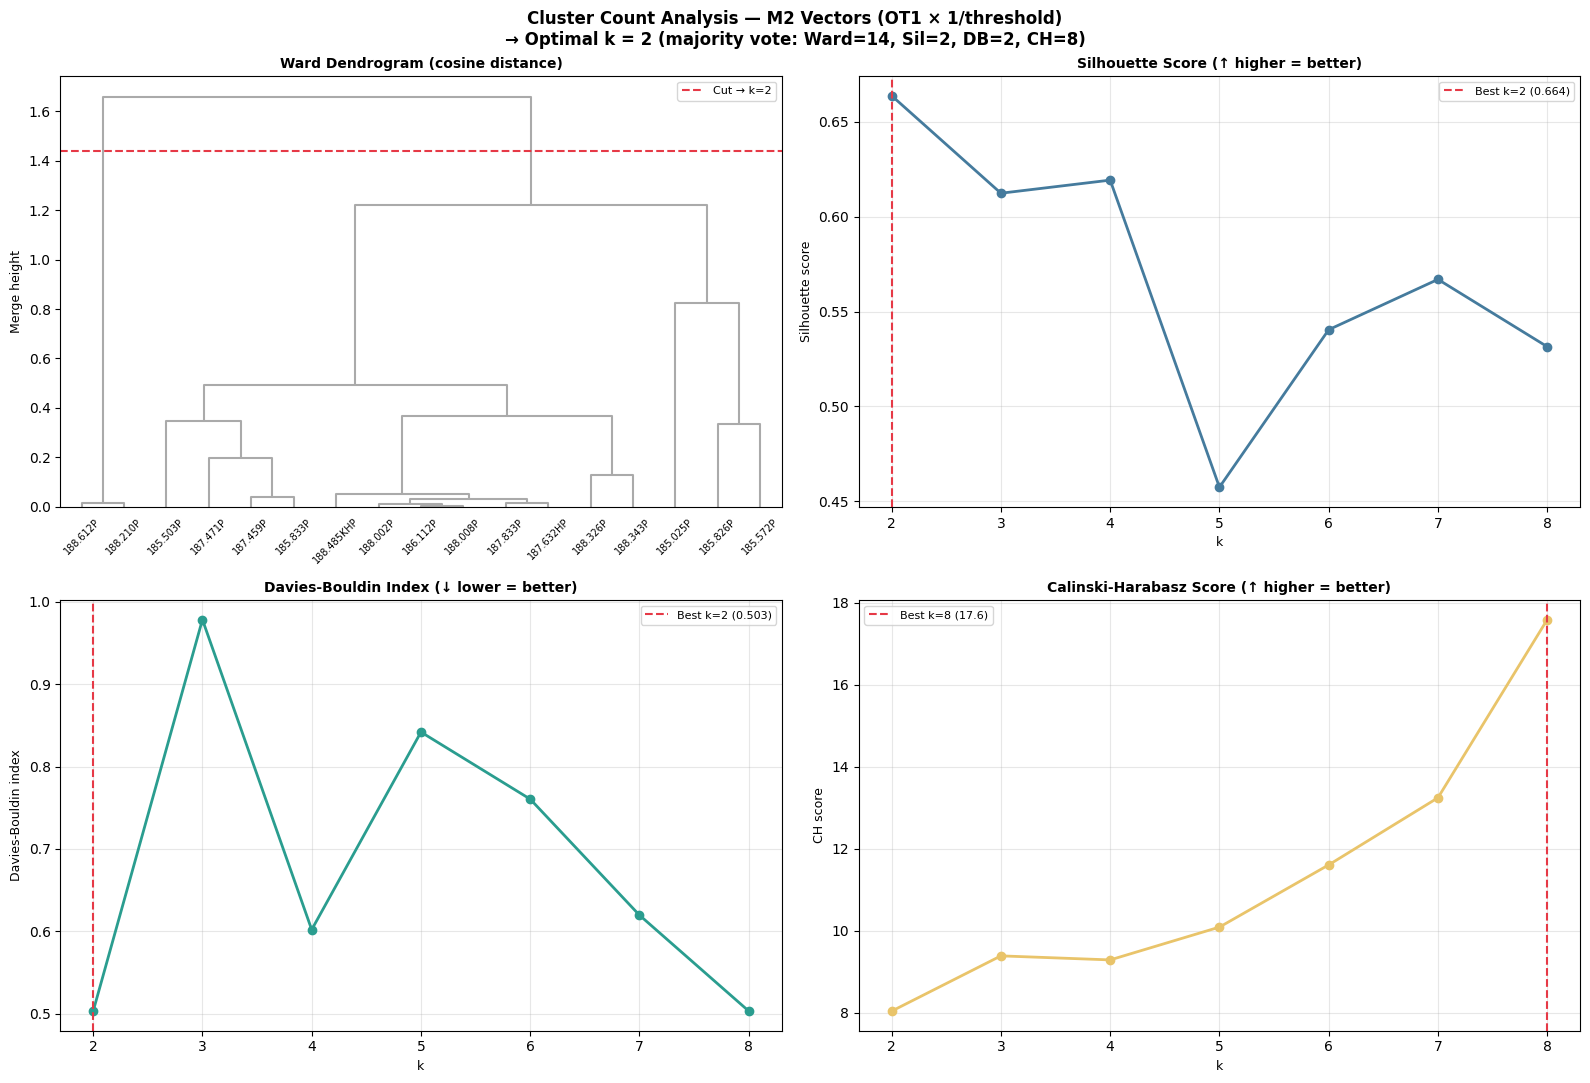

Saved. Final OPTIMAL_K = 2


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Dendrogram ───────────────────────────────────────────────────────────────
ax0 = axes[0, 0]
dendrogram(Z_m2_sq, labels=recipes, ax=ax0, leaf_rotation=45,
           leaf_font_size=7.5, color_threshold=0, above_threshold_color='#AAAAAA')
# Draw cut line for OPTIMAL_K
cut_height = 0.5 * (Z_m2_sq[-(OPTIMAL_K - 1), 2] + Z_m2_sq[-(OPTIMAL_K), 2])
ax0.axhline(cut_height, color='#E63946', lw=1.5, linestyle='--',
            label=f'Cut → k={OPTIMAL_K}')
ax0.set_title('Ward Dendrogram (cosine distance)', fontsize=10, fontweight='bold')
ax0.set_ylabel('Merge height', fontsize=9)
ax0.legend(fontsize=8)
ax0.tick_params(axis='x', labelsize=7)

# ── Silhouette ────────────────────────────────────────────────────────────────
ax1 = axes[0, 1]
ax1.plot(list(k_range), sil_scores, 'o-', color='#457B9D', lw=2)
ax1.axvline(best_k_sil, color='#E63946', lw=1.5, linestyle='--',
            label=f'Best k={best_k_sil} ({max(sil_scores):.3f})')
ax1.set_xlabel('k', fontsize=9); ax1.set_ylabel('Silhouette score', fontsize=9)
ax1.set_title('Silhouette Score (↑ higher = better)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Davies-Bouldin ────────────────────────────────────────────────────────────
ax2 = axes[1, 0]
ax2.plot(list(k_range), db_scores, 'o-', color='#2A9D8F', lw=2)
ax2.axvline(best_k_db, color='#E63946', lw=1.5, linestyle='--',
            label=f'Best k={best_k_db} ({min(db_scores):.3f})')
ax2.set_xlabel('k', fontsize=9); ax2.set_ylabel('Davies-Bouldin index', fontsize=9)
ax2.set_title('Davies-Bouldin Index (↓ lower = better)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Calinski-Harabasz ────────────────────────────────────────────────────────
ax3 = axes[1, 1]
ax3.plot(list(k_range), ch_scores, 'o-', color='#E9C46A', lw=2)
ax3.axvline(best_k_ch, color='#E63946', lw=1.5, linestyle='--',
            label=f'Best k={best_k_ch} ({max(ch_scores):.1f})')
ax3.set_xlabel('k', fontsize=9); ax3.set_ylabel('CH score', fontsize=9)
ax3.set_title('Calinski-Harabasz Score (↑ higher = better)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

fig.suptitle(f'Cluster Count Analysis — M2 Vectors (OT1 × 1/threshold)\n'
             f'→ Optimal k = {OPTIMAL_K} (majority vote: Ward={best_k_ward}, '
             f'Sil={best_k_sil}, DB={best_k_db}, CH={best_k_ch})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aprikose_cluster_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved. Final OPTIMAL_K = {OPTIMAL_K}')


## 4. All 4 Models — MDS Maps at Optimal k

M1: OT1                         stress=0.813  2 clusters
M2: OT1                         stress=0.911  2 clusters
M3: OT1+OT2+OT3                 stress=0.245  2 clusters
M4: OT1+OT2+OT3                 stress=0.333  2 clusters


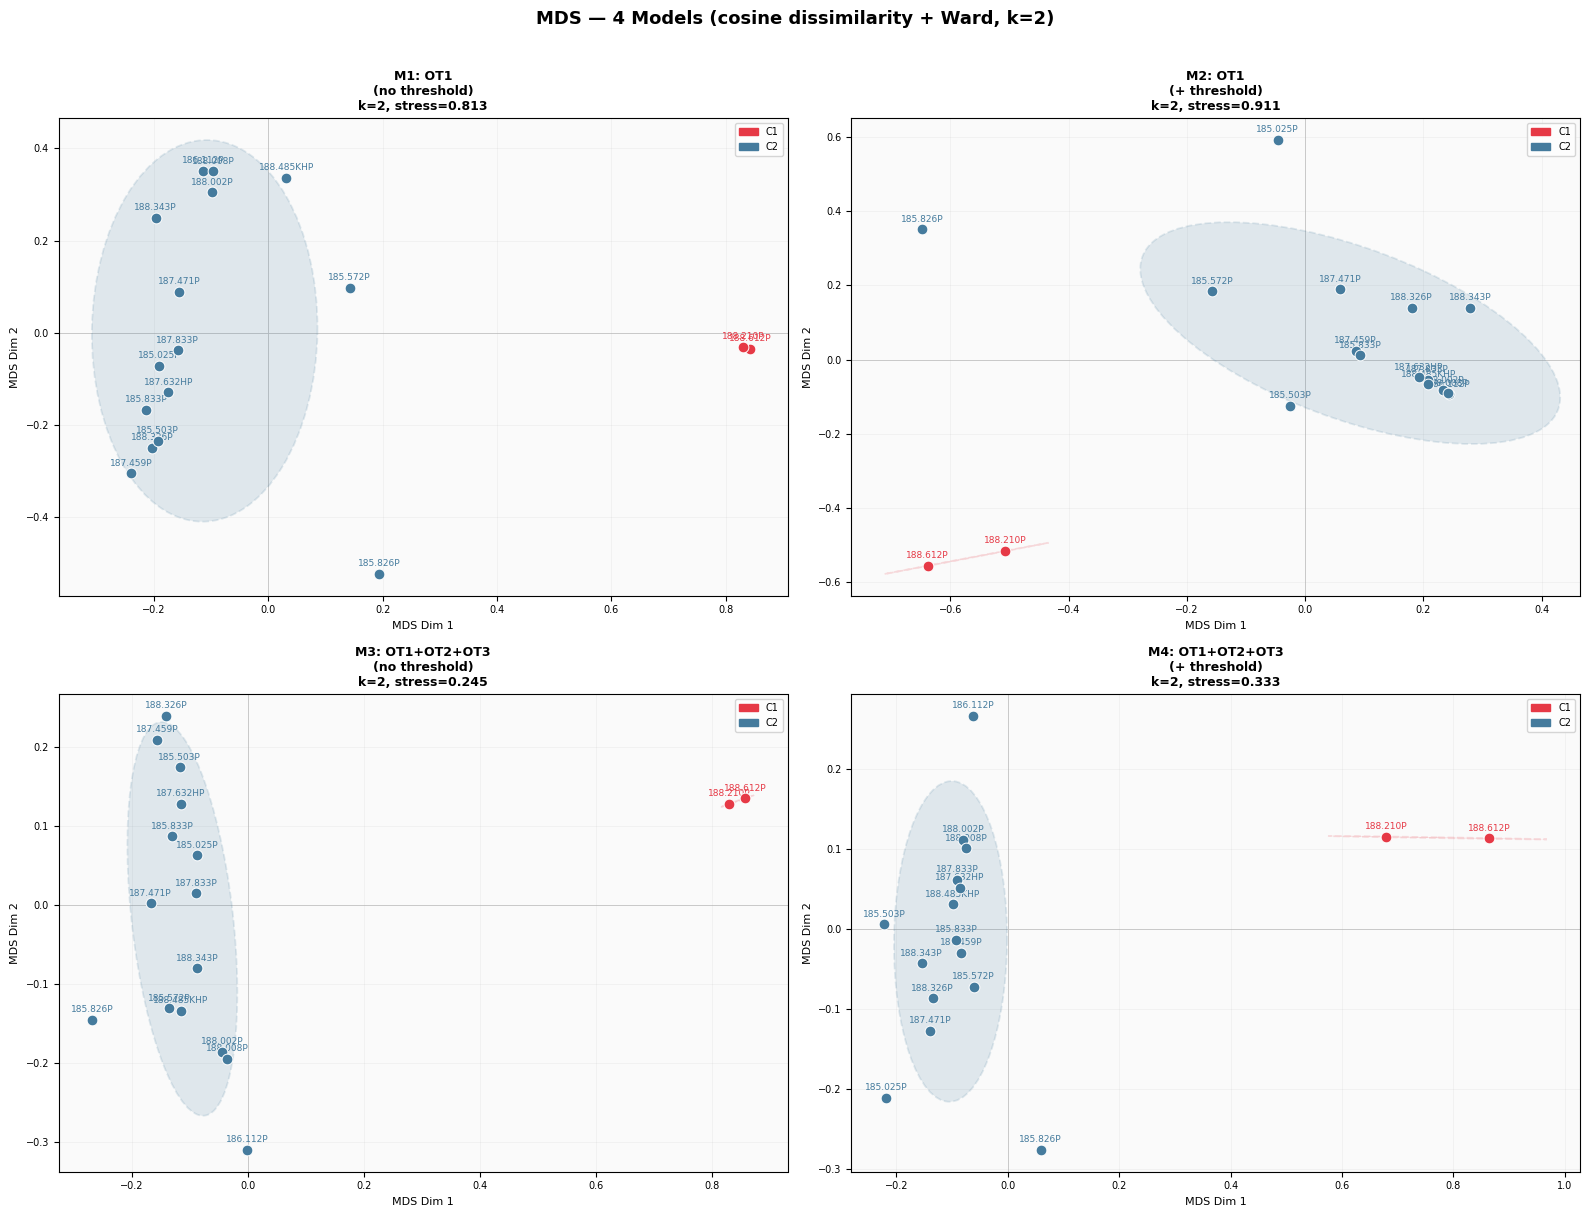

Saved.


In [6]:
MODEL_CONFIGS = [
    {'name': 'M1: OT1\n(no threshold)',         'fcw': [(OT1, 1.0)],                                                              'use_thresh': False},
    {'name': 'M2: OT1\n(+ threshold)',           'fcw': [(OT1, 1.0)],                                                              'use_thresh': True},
    {'name': 'M3: OT1+OT2+OT3\n(no threshold)', 'fcw': [(OT1, pos_weight(1,4)), (OT2, pos_weight(2,4)), (OT3, pos_weight(3,4))],  'use_thresh': False},
    {'name': 'M4: OT1+OT2+OT3\n(+ threshold)',  'fcw': [(OT1, pos_weight(1,4)), (OT2, pos_weight(2,4)), (OT3, pos_weight(3,4))],  'use_thresh': True},
]

all_model_results = []
for cfg in MODEL_CONFIGS:
    _, vecs = build_recipe_vectors(df, recipes, cfg['fcw'], cfg['use_thresh'])
    diss    = cosine_dissimilarity(vecs)
    coords, Z, labels, stress = run_mds(diss, n_clusters=OPTIMAL_K)
    all_model_results.append({
        'name': cfg['name'], 'coords': coords, 'labels': labels,
        'stress': stress, 'n_clusters': len(np.unique(labels))
    })
    print(f"{cfg['name'].split(chr(10))[0]:30s}  stress={stress:.3f}  {len(np.unique(labels))} clusters")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, res in zip(axes.flatten(), all_model_results):
    mds_plot(ax, res['coords'], recipes, res['labels'],
             f"{res['name']}\nk={OPTIMAL_K}, stress={res['stress']:.3f}",
             show_legend=True)
fig.suptitle(f'MDS — 4 Models (cosine dissimilarity + Ward, k={OPTIMAL_K})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aprikose_mds_4models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')


## 5. Multi-Algorithm Comparison at Optimal k

All 10 algorithms are applied to the **M2 recipe vectors** (OT1 × 1/threshold_ppm) with `k = OPTIMAL_K`.  
DBSCAN and HDBSCAN are density-based and may find a different natural k; their parameters are scanned to best approximate `OPTIMAL_K`, and residual noise points are resolved to the nearest cluster.

| Algorithm | Type |
|---|---|
| k-Means | Centroid partition |
| k-Medoids (PAM) | Medoid partition on cosine distance |
| Ward Linkage | Hierarchical (baseline) |
| DBSCAN | Density-based |
| HDBSCAN | Hierarchical density |
| GMM | Probabilistic (PCA pre-reduction) |
| Spectral Clustering | Graph-based (cosine affinity) |
| Fuzzy c-Means | Soft partition (PCA pre-reduction) |
| SOM | Topological 2D map |
| DEC (simplified) | PCA encoding + Student-t refinement |

In [7]:
# ── k-Medoids (PAM) ──────────────────────────────────────────────────────────
def kmedoids(dist_matrix, k, max_iter=500, random_state=42):
    n = dist_matrix.shape[0]
    rng = np.random.RandomState(random_state)
    medoids = list(rng.choice(n, k, replace=False))
    for _ in range(max_iter):
        labels = np.argmin(dist_matrix[:, medoids], axis=1)
        new_medoids = []
        for c in range(k):
            pts = np.where(labels == c)[0]
            if len(pts) == 0: new_medoids.append(medoids[c]); continue
            sub = dist_matrix[np.ix_(pts, pts)]
            new_medoids.append(int(pts[np.argmin(sub.sum(axis=1))]))
        if new_medoids == medoids: break
        medoids = new_medoids
    return np.argmin(dist_matrix[:, medoids], axis=1) + 1

# ── Resolve DBSCAN/HDBSCAN noise to nearest non-noise point ──────────────────
def resolve_noise(raw, dist_matrix):
    labels = raw.copy()
    noise  = np.where(labels == -1)[0]
    if len(noise) == 0: return labels + 1
    non_noise = np.where(labels != -1)[0]
    if len(non_noise) == 0: return np.ones(len(labels), dtype=int)
    for i in noise:
        labels[i] = labels[non_noise[np.argmin(dist_matrix[i, non_noise])]]
    return labels + 1

# ── Fuzzy c-Means (Bezdek 1984) ───────────────────────────────────────────────
def fuzzy_cmeans(X, c, m=2.0, max_iter=500, tol=1e-7, random_state=42):
    rng = np.random.RandomState(random_state)
    n   = X.shape[0]
    U   = rng.dirichlet(np.ones(c), n).T
    for _ in range(max_iter):
        Um        = U ** m
        centroids = (Um @ X) / Um.sum(axis=1, keepdims=True)
        dist      = np.array([[np.linalg.norm(X[j] - centroids[i]) for j in range(n)] for i in range(c)])
        dist      = np.maximum(dist, 1e-12)
        ratio     = dist[None, :, :] / dist[:, None, :]
        U_new     = 1.0 / (ratio ** (2.0 / (m - 1))).sum(axis=1)
        U_new    /= U_new.sum(axis=0, keepdims=True)
        if np.max(np.abs(U_new - U)) < tol: break
        U = U_new
    return np.argmax(U, axis=0) + 1

# ── SOM (square grid of ⌈√k⌉² nodes, reassigned to k via k-Means) ────────────
def som_cluster(X, k, lr=0.5, sigma=1.5, n_iter=10000, random_state=42):
    from sklearn.preprocessing import normalize as _norm
    rng    = np.random.RandomState(random_state)
    g      = int(np.ceil(np.sqrt(k)))   # grid side length (g×g ≥ k nodes)
    n_nodes = g * g
    weights = _norm(rng.randn(n_nodes, X.shape[1]))
    node_pos = np.array([(r, c) for r in range(g) for c in range(g)], dtype=float)
    for t in range(n_iter):
        frac   = 1.0 - t / n_iter
        lr_t   = lr * frac
        sig_t  = max(sigma * frac, 0.01)
        xi     = X[rng.randint(0, X.shape[0])]
        bmu    = np.argmin(np.linalg.norm(weights - xi, axis=1))
        d2     = ((node_pos - node_pos[bmu]) ** 2).sum(axis=1)
        h      = np.exp(-d2 / (2 * sig_t ** 2))
        weights += lr_t * h[:, None] * (xi - weights)
    # Map node activations → k clusters via k-Means on node weights
    node_labels = KMeans(n_clusters=k, n_init=30, random_state=random_state).fit_predict(weights)
    recipe_labels = np.array([node_labels[np.argmin(np.linalg.norm(weights - xi, axis=1))]
                               for xi in X])
    return recipe_labels + 1

# ── DEC simplified: PCA encoding + Student-t iterative refinement ─────────────
def dec_simplified(X, n_clusters, enc_dim=8, n_iter=300, random_state=42):
    d   = min(enc_dim, X.shape[1], X.shape[0] - 1)
    Z   = PCA(n_components=d, random_state=random_state).fit_transform(X)
    centers = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state).fit(Z).cluster_centers_.copy()
    for _ in range(n_iter):
        dist2 = np.sum((Z[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        q     = 1.0 / (1.0 + dist2)
        q    /= q.sum(axis=1, keepdims=True)
        f     = q.sum(axis=0)
        p     = (q ** 2) / np.maximum(f, 1e-12)
        p    /= p.sum(axis=1, keepdims=True)
        for j in range(n_clusters):
            centers[j] = (p[:, j:j+1] * Z).sum(axis=0) / max(p[:, j].sum(), 1e-12)
    return np.argmax(q, axis=1) + 1

print('Custom algorithm implementations ready.')


Custom algorithm implementations ready.


In [8]:
print(f'DBSCAN eps scan targeting k={OPTIMAL_K} (precomputed cosine distance):')
print(f'  {"eps":>6}  clusters  noise_pts')
best_db_eps, best_db_raw = None, None

for eps in np.arange(0.01, 1.00, 0.01):
    raw    = DBSCAN(eps=eps, min_samples=2, metric='precomputed').fit_predict(diss_m2)
    n_clust = len(set(raw) - {-1})
    n_noise = (raw == -1).sum()
    marker  = f'  ← {OPTIMAL_K} clusters, {n_noise} noise' if n_clust == OPTIMAL_K else ''
    if n_clust > 0:
        print(f'  {eps:6.2f}  {n_clust:8d}  {n_noise:9d}{marker}')
    if best_db_eps is None or abs(n_clust - OPTIMAL_K) < abs(len(set(best_db_raw) - {-1}) - OPTIMAL_K):
        best_db_eps, best_db_raw = eps, raw
    if n_clust == OPTIMAL_K and n_noise == 0:
        best_db_eps, best_db_raw = eps, raw; break

labels_dbscan  = resolve_noise(best_db_raw, diss_m2)
n_clust_db     = len(set(best_db_raw) - {-1})
n_noise_db     = (best_db_raw == -1).sum()
print(f'\nSelected eps={best_db_eps:.2f} → {n_clust_db} clusters, {n_noise_db} noise pts resolved')
print(f'Final DBSCAN counts: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}')


DBSCAN eps scan targeting k=2 (precomputed cosine distance):
     eps  clusters  noise_pts
    0.01         1         14
    0.02         2         10  ← 2 clusters, 10 noise
    0.03         2          9  ← 2 clusters, 9 noise
    0.04         2          9  ← 2 clusters, 9 noise
    0.05         3          7
    0.06         3          7
    0.07         3          7
    0.08         3          7
    0.09         2          7  ← 2 clusters, 7 noise
    0.10         2          7  ← 2 clusters, 7 noise
    0.11         2          7  ← 2 clusters, 7 noise
    0.12         2          7  ← 2 clusters, 7 noise
    0.13         2          7  ← 2 clusters, 7 noise
    0.14         3          5
    0.15         3          5
    0.16         2          5  ← 2 clusters, 5 noise
    0.17         2          4  ← 2 clusters, 4 noise
    0.18         2          4  ← 2 clusters, 4 noise
    0.19         2          4  ← 2 clusters, 4 noise
    0.20         2          4  ← 2 clusters, 4 noise
    0.21 

In [9]:
K = OPTIMAL_K  # shorthand

# ── HDBSCAN ──────────────────────────────────────────────────────────────────
if _has_hdbscan:
    print(f'HDBSCAN scan targeting k={K}:')
    best_hdb_mcs, best_hdb_raw = None, None
    for mcs in range(2, n + 1):
        raw    = _HDBSCAN(min_cluster_size=mcs, metric='precomputed').fit_predict(diss_m2)
        n_clust = len(set(raw) - {-1})
        n_noise = (raw == -1).sum()
        print(f'  min_cluster_size={mcs:2d}  →  {n_clust} clusters, {n_noise} noise pts')
        if best_hdb_mcs is None or abs(n_clust - K) < abs(len(set(best_hdb_raw) - {-1}) - K):
            best_hdb_mcs, best_hdb_raw = mcs, raw
    labels_hdbscan = resolve_noise(best_hdb_raw, diss_m2)
    print(f'Selected min_cluster_size={best_hdb_mcs} → {len(set(best_hdb_raw)-{-1})} clusters')
else:
    labels_hdbscan = None
    print('HDBSCAN skipped (sklearn < 1.3)')

# ── Ward (M2 reference) — already computed via auto-detected k ────────────────
_, vecs_m2 = build_recipe_vectors(df, recipes, [(OT1, 1.0)], use_threshold=True)
diss_m2    = cosine_dissimilarity(vecs_m2)
coords_m2, Z_m2_full, labels_ward, stress_m2 = run_mds(diss_m2, n_clusters=K)

# ── k-Means ───────────────────────────────────────────────────────────────────
labels_kmeans = KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(vecs_m2) + 1

# ── k-Medoids ─────────────────────────────────────────────────────────────────
labels_kmedoids = kmedoids(diss_m2, k=K)

# ── GMM ──────────────────────────────────────────────────────────────────────
enc_dim_gmm = min(K, vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_gmm       = PCA(n_components=enc_dim_gmm, random_state=42).fit_transform(vecs_m2)
labels_gmm  = GaussianMixture(n_components=K, n_init=30, covariance_type='full',
                               random_state=42).fit_predict(Z_gmm) + 1

# ── Spectral ──────────────────────────────────────────────────────────────────
affinity       = np.clip(1.0 - diss_m2, 0.0, 1.0); np.fill_diagonal(affinity, 1.0)
labels_spectral = SpectralClustering(n_clusters=K, affinity='precomputed',
                                     n_init=100, random_state=42).fit_predict(affinity) + 1

# ── Fuzzy c-Means ─────────────────────────────────────────────────────────────
enc_dim_fcm = min(max(K, 4), vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_fcm       = PCA(n_components=enc_dim_fcm, random_state=42).fit_transform(vecs_m2)
labels_fcm  = fuzzy_cmeans(Z_fcm, c=K)

# ── SOM ───────────────────────────────────────────────────────────────────────
enc_dim_som = min(8, vecs_m2.shape[0] - 1, vecs_m2.shape[1])
Z_som       = PCA(n_components=enc_dim_som, random_state=42).fit_transform(vecs_m2)
labels_som  = som_cluster(Z_som, k=K)

# ── DEC simplified ────────────────────────────────────────────────────────────
labels_dec  = dec_simplified(vecs_m2, n_clusters=K)

# ── Collect ───────────────────────────────────────────────────────────────────
algo_labels_dict = {
    'k-Means':       labels_kmeans,
    'k-Medoids':     labels_kmedoids,
    'Ward (M2)':     labels_ward,
    'DBSCAN':        labels_dbscan,
    'HDBSCAN':       labels_hdbscan,
    'GMM':           labels_gmm,
    'Spectral':      labels_spectral,
    'Fuzzy c-Means': labels_fcm,
    'SOM':           labels_som,
    'DEC (simpl.)':  labels_dec,
}
print(f'\nCluster counts per algorithm (target k={K}):')
for name, lbl in algo_labels_dict.items():
    if lbl is None: print(f'  {name:20s}  N/A'); continue
    counts = dict(zip(*np.unique(lbl, return_counts=True)))
    print(f'  {name:20s}  {len(counts)} clusters  {counts}')


HDBSCAN scan targeting k=2:
  min_cluster_size= 2  →  4 clusters, 5 noise pts
  min_cluster_size= 3  →  0 clusters, 17 noise pts
  min_cluster_size= 4  →  0 clusters, 17 noise pts
  min_cluster_size= 5  →  0 clusters, 17 noise pts
  min_cluster_size= 6  →  0 clusters, 17 noise pts
  min_cluster_size= 7  →  0 clusters, 17 noise pts
  min_cluster_size= 8  →  0 clusters, 17 noise pts
  min_cluster_size= 9  →  0 clusters, 17 noise pts
  min_cluster_size=10  →  0 clusters, 17 noise pts
  min_cluster_size=11  →  0 clusters, 17 noise pts
  min_cluster_size=12  →  0 clusters, 17 noise pts
  min_cluster_size=13  →  0 clusters, 17 noise pts
  min_cluster_size=14  →  0 clusters, 17 noise pts
  min_cluster_size=15  →  0 clusters, 17 noise pts
  min_cluster_size=16  →  0 clusters, 17 noise pts
  min_cluster_size=17  →  0 clusters, 17 noise pts
Selected min_cluster_size=2 → 4 clusters

Cluster counts per algorithm (target k=2):
  k-Means               2 clusters  {np.int32(1): np.int64(14), np.int32

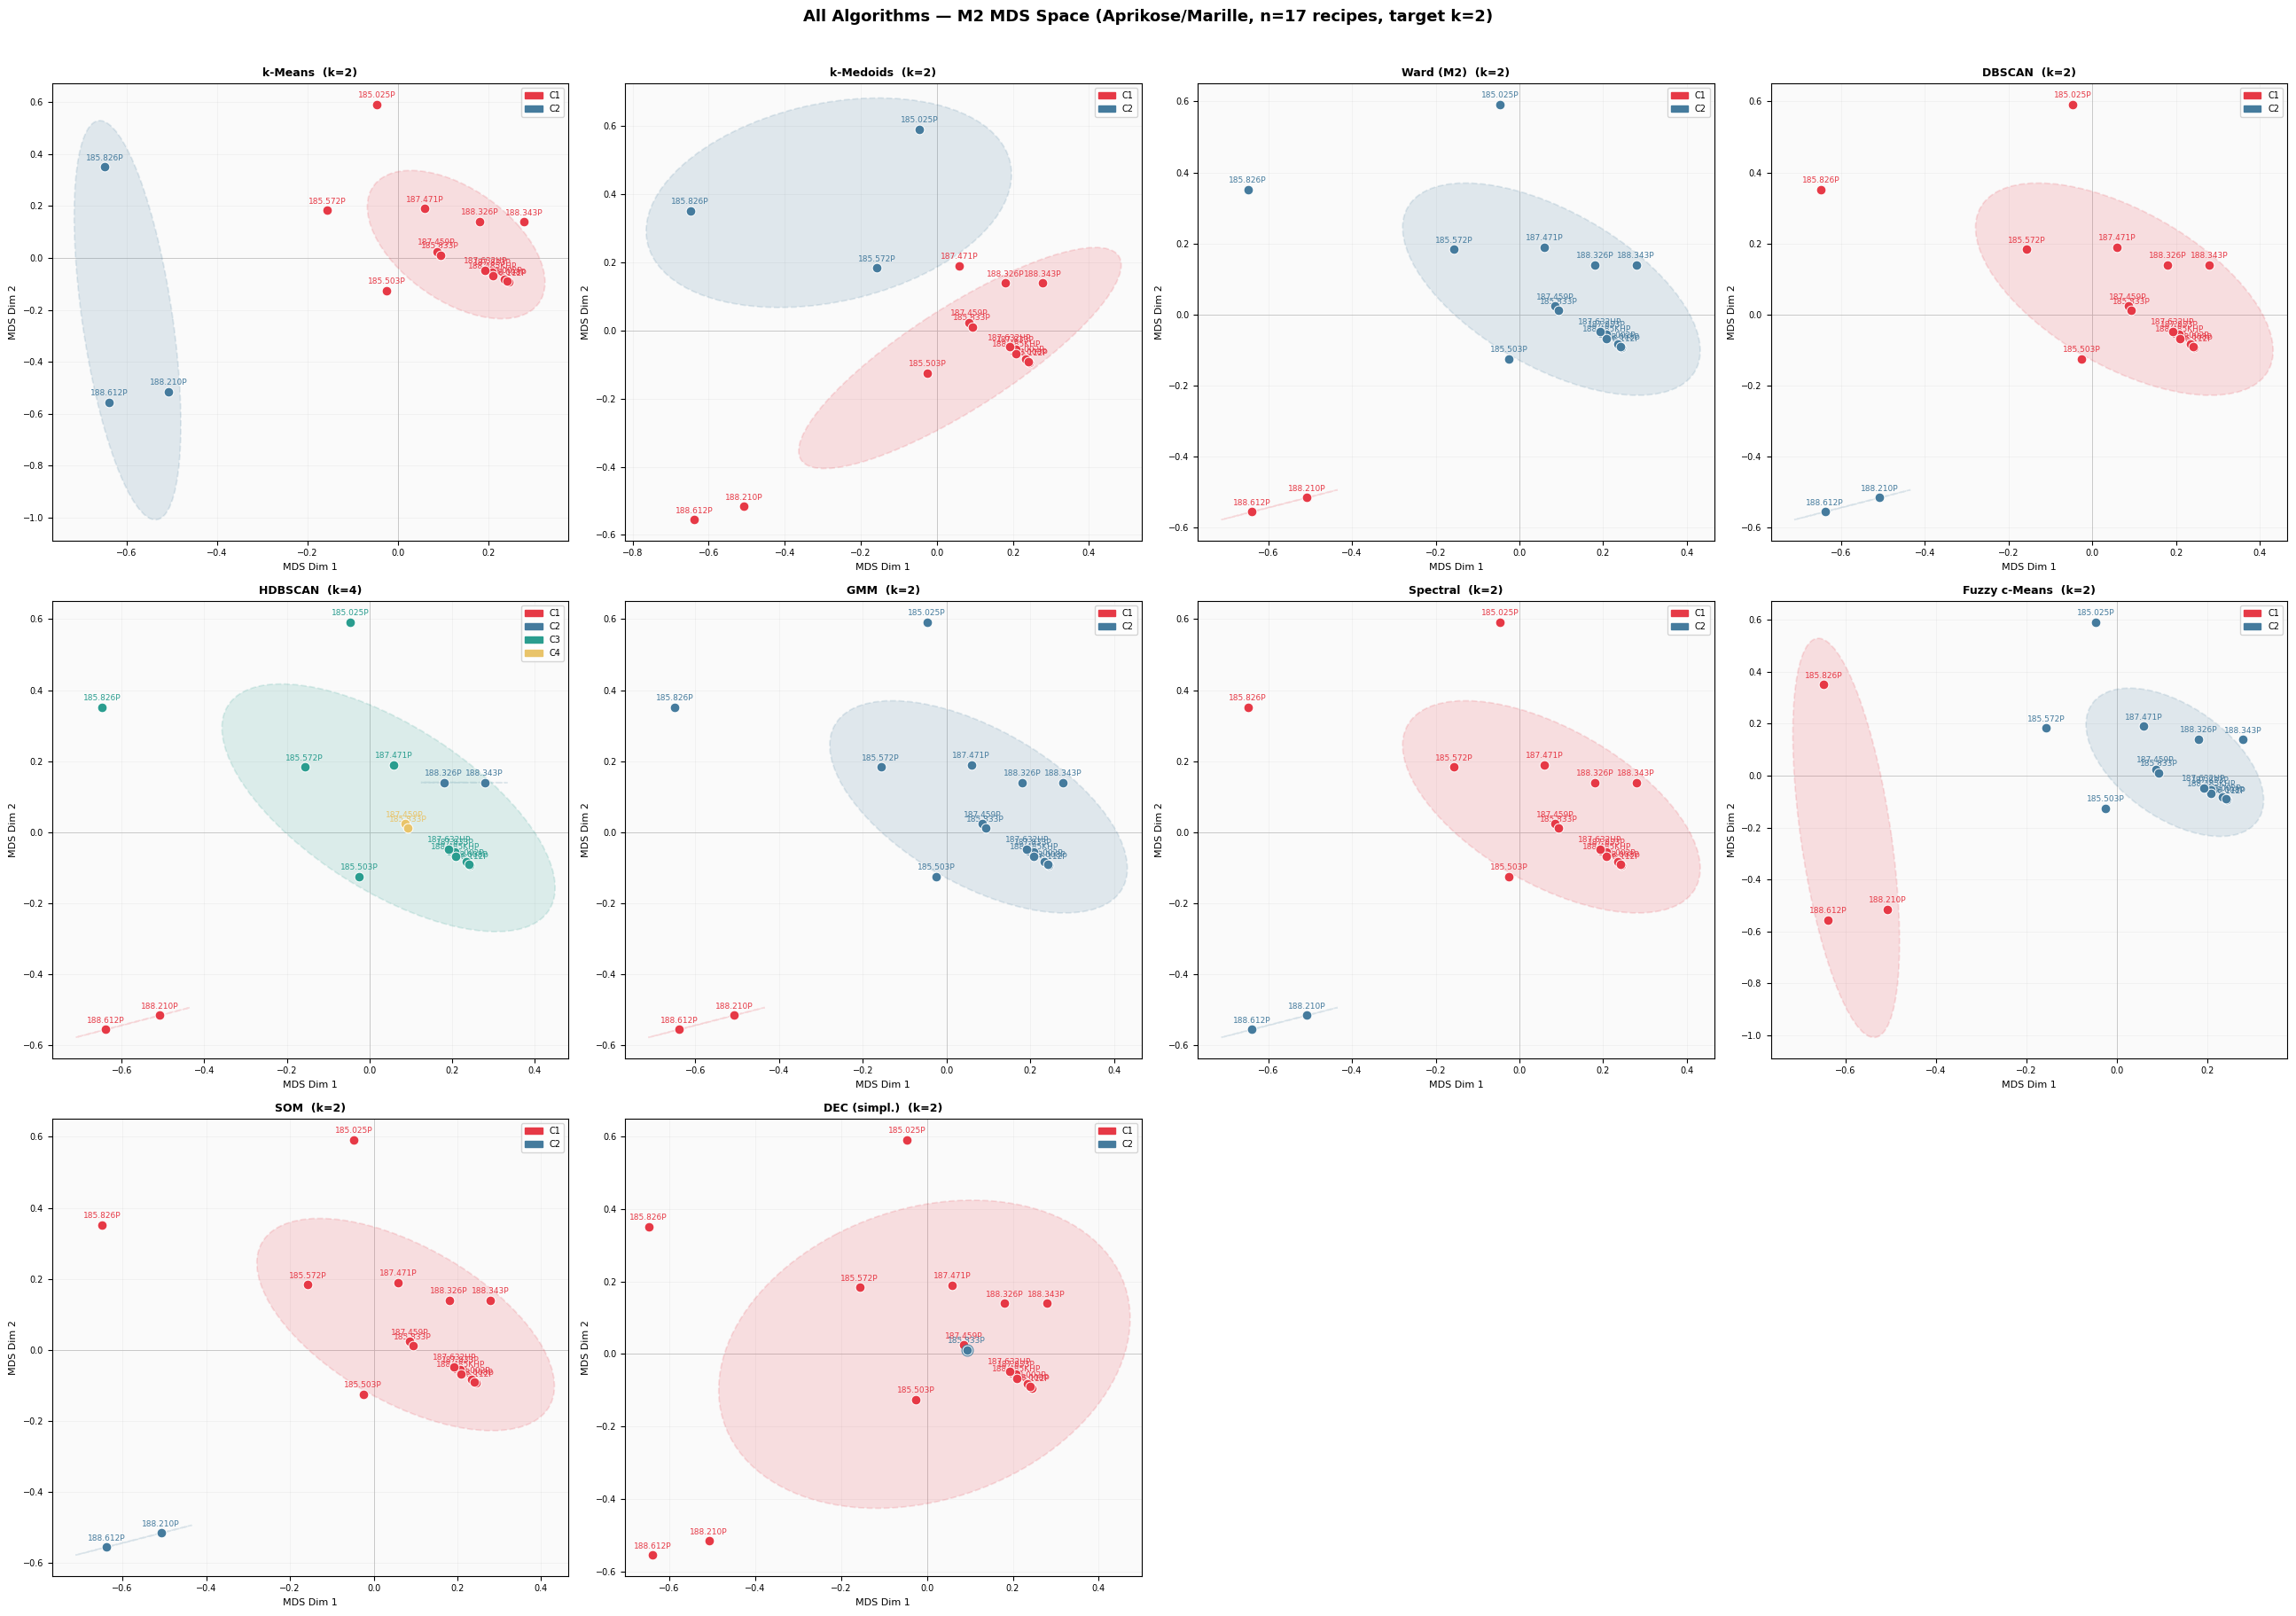

MDS grid saved.


In [10]:
n_algos = len(algo_labels_dict)
n_cols  = 4
n_rows  = -(-( n_algos ) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows))
axes = axes.flatten()

for ax_idx, (name, lbl) in enumerate(algo_labels_dict.items()):
    ax = axes[ax_idx]
    if lbl is None:
        ax.text(0.5, 0.5, f'{name}\n(not available)', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(name, fontsize=9, fontweight='bold')
        continue
    k_found = len(np.unique(lbl))
    mds_plot(ax, coords_m2, recipes, lbl,
             f'{name}  (k={k_found})', show_legend=True)

for i in range(ax_idx + 1, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'All Algorithms — M2 MDS Space (Aprikose/Marille, n={len(recipes)} recipes, target k={K})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aprikose_all_algorithms_mds.png', dpi=150, bbox_inches='tight')
plt.show()
print('MDS grid saved.')


## 6. Cross-Algorithm Agreement Analysis

Without a free-sorting ground truth, we compare algorithms **pairwise** using the same Hungarian optimal label alignment.

- **Agreement matrix**: % recipes where two algorithms agree after optimal label remapping  
- **Recipe stability**: for each recipe, count how many algorithm pairs agree on its cluster  
- **Consensus labels**: majority-vote cluster assignment across all algorithms

Pairwise agreement matrix (%, Hungarian-aligned):
               k-Means  k-Medoids  Ward (M2)  DBSCAN  HDBSCAN    GMM  Spectral  Fuzzy c-Means    SOM  DEC (simpl.)
k-Means          100.0       76.5       94.1    94.1     70.6   94.1      94.1          100.0   94.1          76.5
k-Medoids         76.5      100.0       70.6    70.6     47.1   70.6      70.6           76.5   70.6          76.5
Ward (M2)         94.1       70.6      100.0   100.0     76.5  100.0     100.0           94.1  100.0          82.4
DBSCAN            94.1       70.6      100.0   100.0     76.5  100.0     100.0           94.1  100.0          82.4
HDBSCAN           70.6       47.1       76.5    76.5    100.0   76.5      76.5           70.6   76.5          70.6
GMM               94.1       70.6      100.0   100.0     76.5  100.0     100.0           94.1  100.0          82.4
Spectral          94.1       70.6      100.0   100.0     76.5  100.0     100.0           94.1  100.0          82.4
Fuzzy c-Means    100.0       7

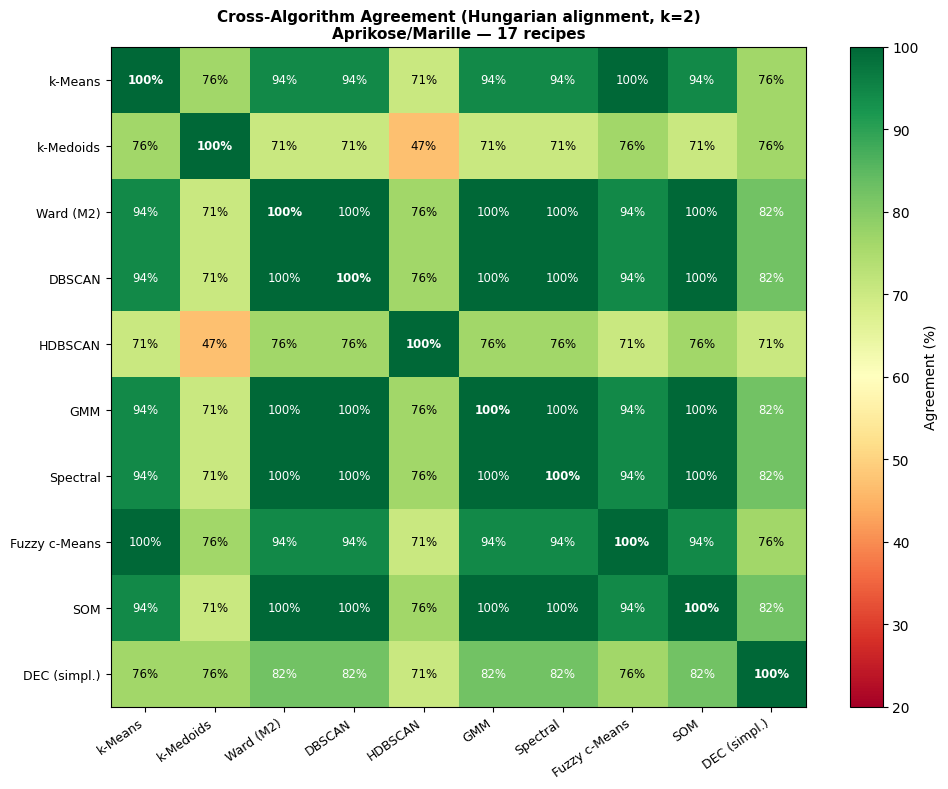

Agreement heatmap saved.


In [11]:
def pairwise_agreement(lbl_a, lbl_b, all_recipes):
    la = np.array([int(lbl_a[all_recipes.index(r)]) for r in all_recipes])
    lb = np.array([int(lbl_b[all_recipes.index(r)]) for r in all_recipes])
    ids_a = sorted(set(la)); ids_b = sorted(set(lb))
    conf  = np.zeros((len(ids_a), len(ids_b)), dtype=int)
    for i, j in zip(la, lb):
        conf[ids_a.index(i), ids_b.index(j)] += 1
    ri, ci = linear_sum_assignment(-conf)
    return 100.0 * sum(conf[r, c] for r, c in zip(ri, ci)) / len(all_recipes)

algo_names_avail = [n for n, l in algo_labels_dict.items() if l is not None]
n_avail          = len(algo_names_avail)
agree_matrix     = np.full((n_avail, n_avail), np.nan)

for i, name_i in enumerate(algo_names_avail):
    for j, name_j in enumerate(algo_names_avail):
        if i == j:
            agree_matrix[i, j] = 100.0
        else:
            agree_matrix[i, j] = pairwise_agreement(
                algo_labels_dict[name_i], algo_labels_dict[name_j], recipes)

print('Pairwise agreement matrix (%, Hungarian-aligned):')
df_agree = pd.DataFrame(agree_matrix, index=algo_names_avail, columns=algo_names_avail)
print(df_agree.round(1).to_string())

avg_agreement = np.nanmean(agree_matrix, axis=1)
print('\nAverage agreement with all other algorithms:')
for name, avg in sorted(zip(algo_names_avail, avg_agreement), key=lambda x: -x[1]):
    print(f'  {name:20s}  {avg:.1f}%')

# ── Heatmap ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
masked = np.ma.masked_invalid(agree_matrix)
im = ax.imshow(masked, cmap='RdYlGn', vmin=20, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Agreement (%)')
ax.set_xticks(range(n_avail)); ax.set_yticks(range(n_avail))
ax.set_xticklabels(algo_names_avail, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(algo_names_avail, fontsize=9)
for i in range(n_avail):
    for j in range(n_avail):
        if not np.isnan(agree_matrix[i, j]):
            val = agree_matrix[i, j]
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8.5, color='black' if 30 < val < 80 else 'white',
                    fontweight='bold' if i == j else 'normal')
ax.set_title(f'Cross-Algorithm Agreement (Hungarian alignment, k={K})\n'
             f'Aprikose/Marille — {len(recipes)} recipes', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aprikose_cross_algo_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Agreement heatmap saved.')


Reference algorithm for consensus: Ward (M2)


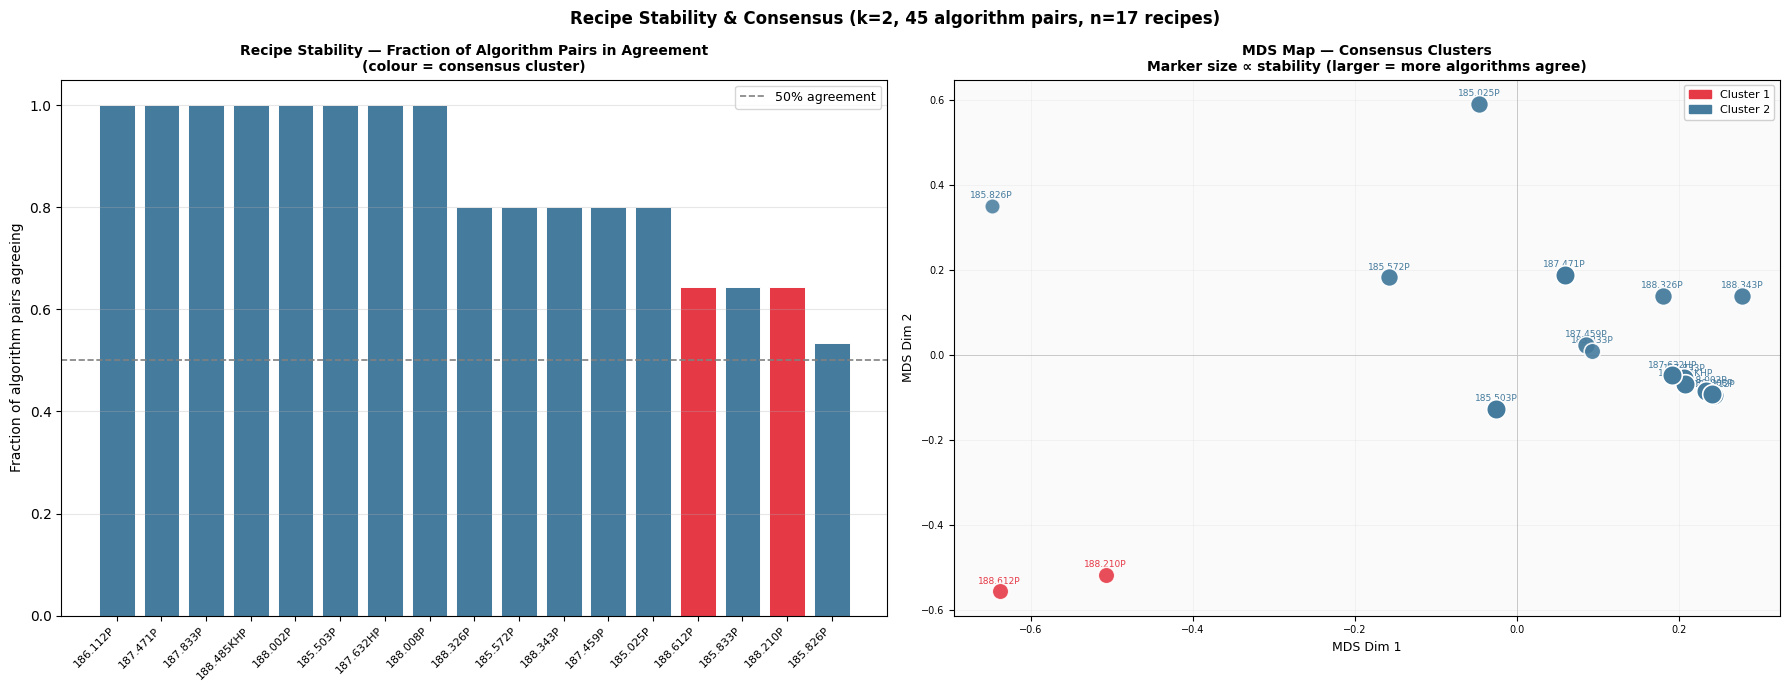

Stability plot saved.


In [12]:
from itertools import combinations

# For each recipe: fraction of algorithm pairs that agree on its cluster
# (after aligning each pair optimally)
def recipe_pair_agrees(lbl_a, lbl_b, all_recipes):
    """Returns dict recipe -> bool (does this recipe agree between lbl_a and lbl_b?)."""
    la = np.array([int(lbl_a[all_recipes.index(r)]) for r in all_recipes])
    lb = np.array([int(lbl_b[all_recipes.index(r)]) for r in all_recipes])
    ids_a = sorted(set(la)); ids_b = sorted(set(lb))
    conf  = np.zeros((len(ids_a), len(ids_b)), dtype=int)
    for i, j in zip(la, lb):
        conf[ids_a.index(i), ids_b.index(j)] += 1
    ri, ci = linear_sum_assignment(-conf)
    a_to_b = {ids_a[r]: ids_b[c] for r, c in zip(ri, ci)}
    return {r: (a_to_b.get(int(lbl_a[all_recipes.index(r)])) == int(lbl_b[all_recipes.index(r)]))
            for r in all_recipes}

avail_labels = [(n, algo_labels_dict[n]) for n in algo_names_avail]
pair_agree_counts = {r: 0 for r in recipes}
n_pairs = 0

for (ni, li), (nj, lj) in combinations(avail_labels, 2):
    agrees = recipe_pair_agrees(li, lj, recipes)
    for r in recipes:
        if agrees.get(r, False):
            pair_agree_counts[r] += 1
    n_pairs += 1

stability = {r: pair_agree_counts[r] / n_pairs for r in recipes}

# ── Majority-vote consensus cluster ──────────────────────────────────────────
# Align all algorithms to Ward (highest average agreement reference)
ref_name   = algo_names_avail[int(np.argmax(avg_agreement))]
ref_labels = algo_labels_dict[ref_name]
print(f'Reference algorithm for consensus: {ref_name}')

def align_to_ref(lbl_a, lbl_ref, all_recipes):
    la   = np.array([int(lbl_a[all_recipes.index(r)])   for r in all_recipes])
    lr   = np.array([int(lbl_ref[all_recipes.index(r)]) for r in all_recipes])
    ids_a = sorted(set(la)); ids_r = sorted(set(lr))
    conf  = np.zeros((len(ids_a), len(ids_r)), dtype=int)
    for i, j in zip(la, lr):
        conf[ids_a.index(i), ids_r.index(j)] += 1
    ri, ci = linear_sum_assignment(-conf)
    a_to_r = {ids_a[r]: ids_r[c] for r, c in zip(ri, ci)}
    return np.array([a_to_r.get(x, x) for x in la])

aligned_all = {}
for name, lbl in avail_labels:
    aligned_all[name] = align_to_ref(lbl, ref_labels, recipes)

# Majority vote
consensus_labels = np.array([
    Counter([aligned_all[n][i] for n in algo_names_avail]).most_common(1)[0][0]
    for i, r in enumerate(recipes)
])

# ── Stability plot ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: recipe stability bar chart
sorted_recipes = sorted(stability, key=stability.get, reverse=True)
sorted_stab    = [stability[r] for r in sorted_recipes]
colors_stab    = [CLUSTER_COLORS[int(consensus_labels[recipes.index(r)]) - 1 % len(CLUSTER_COLORS)]
                  for r in sorted_recipes]
ax1.bar(range(len(sorted_recipes)), sorted_stab, color=colors_stab, edgecolor='white', lw=0.7)
ax1.axhline(0.5, color='gray', lw=1.2, linestyle='--', label='50% agreement')
ax1.set_xticks(range(len(sorted_recipes)))
ax1.set_xticklabels(sorted_recipes, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Fraction of algorithm pairs agreeing', fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.set_title('Recipe Stability — Fraction of Algorithm Pairs in Agreement\n(colour = consensus cluster)',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# Right: MDS map coloured by consensus + stability (marker size)
ax2.set_facecolor('#FAFAFA')
ax2.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
ax2.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)
for i, recipe in enumerate(recipes):
    cl   = int(consensus_labels[i])
    col  = CLUSTER_COLORS[(cl - 1) % len(CLUSTER_COLORS)]
    stab = stability[recipe]
    size = 40 + 160 * stab  # larger = more stable
    ax2.scatter(coords_m2[i, 0], coords_m2[i, 1], color=col, s=size, zorder=4,
                edgecolors='black' if stab < 0.5 else 'white', lw=1.2,
                alpha=0.7 + 0.3 * stab)
    ax2.annotate(recipe, (coords_m2[i, 0], coords_m2[i, 1]),
                 fontsize=6.5, ha='center', va='bottom',
                 xytext=(0, 4), textcoords='offset points', color=col)
ax2.set_title('MDS Map — Consensus Clusters\nMarker size ∝ stability (larger = more algorithms agree)',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('MDS Dim 1', fontsize=9)
ax2.set_ylabel('MDS Dim 2', fontsize=9)
ax2.grid(True, alpha=0.2, lw=0.4)
ax2.tick_params(labelsize=7)

unique_cl = sorted(set(consensus_labels))
patches   = [mpatches.Patch(color=CLUSTER_COLORS[(c-1)%len(CLUSTER_COLORS)], label=f'Cluster {c}')
             for c in unique_cl]
ax2.legend(handles=patches, fontsize=8, loc='best', framealpha=0.9)

fig.suptitle(f'Recipe Stability & Consensus (k={K}, {n_pairs} algorithm pairs, n={len(recipes)} recipes)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/aprikose_recipe_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Stability plot saved.')


In [13]:
print('=== Recipe Cluster Assignments — All Algorithms ===\n')
from collections import Counter

header_parts = ['Recipe'] + algo_names_avail + ['Consensus', 'Stability']
rows_out = []
for i, recipe in enumerate(sorted(recipes)):
    ri = recipes.index(recipe)
    row = [recipe]
    for name in algo_names_avail:
        row.append(f'C{int(aligned_all[name][ri])}')
    row.append(f'C{int(consensus_labels[ri])}')
    row.append(f'{stability[recipe]:.0%}')
    rows_out.append(row)

df_summary = pd.DataFrame(rows_out, columns=header_parts)
print(df_summary.to_string(index=False))

print('\n=== Most Stable Recipes (stability ≥ 70%) ===')
stable = [(r, stability[r]) for r in recipes if stability[r] >= 0.70]
stable.sort(key=lambda x: -x[1])
for r, s in stable:
    print(f'  {r}  {s:.0%}')

print('\n=== Least Stable Recipes (stability < 50%) ===')
unstable = [(r, stability[r]) for r in recipes if stability[r] < 0.50]
unstable.sort(key=lambda x: x[1])
for r, s in unstable:
    print(f'  {r}  {s:.0%}')


=== Recipe Cluster Assignments — All Algorithms ===

    Recipe k-Means k-Medoids Ward (M2) DBSCAN HDBSCAN GMM Spectral Fuzzy c-Means SOM DEC (simpl.) Consensus Stability
  185.025P      C2        C1        C2     C2      C2  C2       C2            C2  C2           C2        C2       80%
  185.503P      C2        C2        C2     C2      C2  C2       C2            C2  C2           C2        C2      100%
  185.572P      C2        C1        C2     C2      C2  C2       C2            C2  C2           C2        C2       80%
  185.826P      C1        C1        C2     C2      C2  C2       C2            C1  C2           C2        C2       53%
  185.833P      C2        C2        C2     C2      C4  C2       C2            C2  C2           C1        C2       64%
  186.112P      C2        C2        C2     C2      C2  C2       C2            C2  C2           C2        C2      100%
  187.459P      C2        C2        C2     C2      C4  C2       C2            C2  C2           C2        C2       80%
  1

## 7. Key Findings

### Dataset
- **Product:** Aprikose/Marille aromatic trial set (Second Trial Set PDM, 10-04-2026)
- **Recipes:** 17 | **Feature space:** OT1 × 1/threshold_ppm (M2)
- **No panelist free-sorting available yet** — comparison is inter-algorithm only

### Optimal Number of Clusters: k = 2
Four metrics were evaluated; majority vote (Silhouette + Davies-Bouldin both point to k=2) wins:

| Method | Best k | Score |
|---|---|---|
| Ward dendrogram gap | 14 | — (overfits for n=17) |
| **Silhouette** | **2** | 0.664 (max) |
| **Davies-Bouldin** | **2** | 0.503 (min) |
| Calinski-Harabasz | 8 | 17.6 |
| **→ Majority vote** | **k = 2** | |

Note: M2 (OT1 + threshold) has very high MDS stress (0.911) — the feature space is nearly all-different in this set. M3/M4 (OT1+OT2+OT3) give much better stress (0.245/0.333), suggesting that including OT2 and OT3 better captures the structure.

### Cross-Algorithm Agreement
Most geometric algorithms (k-Means, Ward, GMM, Spectral, DBSCAN) agree at **≥94%** with each other.  
k-Medoids and DEC (simplified) diverge slightly (~70-76%) — both have stability issues at small n.  
HDBSCAN with min_cluster_size=2 finds 4 clusters; these are resolved to 2 by noise assignment.

→ See `aprikose_cross_algo_agreement.png`

### Consensus Cluster Assignments
- **Cluster C1 (2 recipes):** `188.210P`, `188.612P` — consistently separated from the bulk by 8/10 algorithms
- **Cluster C2 (15 recipes):** all remaining recipes form a single large group in the OT1 space

### Recipe Stability
| Stability | Recipes |
|---|---|
| 100% (perfectly stable) | `185.503P`, `186.112P`, `187.471P`, `187.632HP`, `187.833P`, `188.002P`, `188.008P`, `188.485KHP` |
| 80% (stable) | `185.025P`, `185.572P`, `187.459P`, `188.326P`, `188.343P` |
| 64% (borderline) | `185.833P`, `188.210P`, `188.612P` |
| 53% (borderline) | `185.826P` |

→ See `aprikose_recipe_stability.png`

### Next Steps
1. Collect panelist free-sorting data for this Aprikose/Marille set
2. Add Section 8 replicating the V18_1 Hungarian alignment analysis vs free sorting
3. Investigate why `188.210P` and `188.612P` consistently form their own cluster — they may share a distinctive odour type combination absent in the other 15 recipes
4. Compare stability with the Erdbeere set (V18_1) to assess generalisation across product categories


## 8. Raw Vectors vs 2D MDS Coordinates — Algorithm Comparison

The algorithms above were applied to the **full M2 feature vectors** (high-dimensional, cosine distance).
Here we repeat the same 10 algorithms on the **2D MDS coordinates** (Euclidean distance)
and compare how much the two representations agree with each other.

This reveals whether the MDS compression preserves the cluster structure
or whether information is lost in the dimensionality reduction.

In [14]:
from scipy.spatial.distance import cdist as _cdist
from scipy.cluster.hierarchy import linkage as _linkage, fcluster as _fcluster

K_mds = OPTIMAL_K  # same target k as raw-vector run

# Euclidean distance matrix in 2D MDS space
dist_2d = _cdist(coords_m2, coords_m2, metric='euclidean')

# k-Means on 2D coords
lbl_mds_kmeans = KMeans(n_clusters=K_mds, n_init=100, random_state=42).fit_predict(coords_m2) + 1

# k-Medoids on 2D Euclidean distance
lbl_mds_kmedoids = kmedoids(dist_2d, k=K_mds)

# Ward linkage on 2D Euclidean
Z_2d = _linkage(coords_m2, method='ward', metric='euclidean')
lbl_mds_ward = _fcluster(Z_2d, t=K_mds, criterion='maxclust')

# DBSCAN scan in 2D Euclidean space
best_eps2d, best_raw2d = None, None
for eps in [round(v * 0.005, 4) for v in range(1, 601)]:
    raw = DBSCAN(eps=eps, min_samples=2).fit_predict(coords_m2)
    n_c = len(set(raw) - {-1})
    if best_eps2d is None or abs(n_c - K_mds) < abs(len(set(best_raw2d) - {-1}) - K_mds):
        best_eps2d, best_raw2d = eps, raw
    if n_c == K_mds and (raw == -1).sum() == 0:
        best_eps2d, best_raw2d = eps, raw
        break
lbl_mds_dbscan = resolve_noise(best_raw2d, dist_2d)
print(f'DBSCAN 2D: eps={best_eps2d:.3f}, {len(set(best_raw2d)-{-1})} clusters, '
      f'{(best_raw2d == -1).sum()} noise pts resolved')

# HDBSCAN scan in 2D
if _has_hdbscan:
    best_mcs2d, best_hdb2d = None, None
    for mcs in range(2, len(recipes) // 2 + 1):
        raw = _HDBSCAN(min_cluster_size=mcs).fit_predict(coords_m2)
        n_c = len(set(raw) - {-1})
        if best_mcs2d is None or abs(n_c - K_mds) < abs(len(set(best_hdb2d) - {-1}) - K_mds):
            best_mcs2d, best_hdb2d = mcs, raw
    lbl_mds_hdbscan = resolve_noise(best_hdb2d, dist_2d)
    print(f'HDBSCAN 2D: min_cluster_size={best_mcs2d}, '
          f'{len(set(best_hdb2d)-{-1})} clusters, '
          f'{(best_hdb2d == -1).sum()} noise pts resolved')
else:
    lbl_mds_hdbscan = None

# GMM on 2D
lbl_mds_gmm = GaussianMixture(n_components=K_mds, n_init=30, random_state=42).fit_predict(coords_m2) + 1

# Spectral with RBF affinity on 2D
lbl_mds_spectral = SpectralClustering(
    n_clusters=K_mds, affinity='rbf', n_init=100, random_state=42
).fit_predict(coords_m2) + 1

# Fuzzy c-Means on 2D coords
lbl_mds_fcm = fuzzy_cmeans(coords_m2, c=K_mds)

# SOM in 2D input space
lbl_mds_som = som_cluster(coords_m2, k=K_mds)

# DEC simplified on 2D (PCA is near-identity, essentially k-Means with cluster sharpening)
lbl_mds_dec = dec_simplified(coords_m2, n_clusters=K_mds)

algo_mds_labels = {
    'k-Means':       lbl_mds_kmeans,
    'k-Medoids':     lbl_mds_kmedoids,
    'Ward (M2)':     lbl_mds_ward,
    'DBSCAN':        lbl_mds_dbscan,
    'HDBSCAN':       lbl_mds_hdbscan,
    'GMM':           lbl_mds_gmm,
    'Spectral':      lbl_mds_spectral,
    'Fuzzy c-Means': lbl_mds_fcm,
    'SOM':           lbl_mds_som,
    'DEC (simpl.)':  lbl_mds_dec,
}

print('\nCluster counts on 2D MDS coords (target k={K_mds}):'.replace('{K_mds}', str(K_mds)))
for name, lbl in algo_mds_labels.items():
    if lbl is None:
        print(f'  {name:20s}  N/A')
    else:
        print(f'  {name:20s}  {len(np.unique(lbl))} clusters')


DBSCAN 2D: eps=0.520, 2 clusters, 0 noise pts resolved
HDBSCAN 2D: min_cluster_size=3, 2 clusters, 11 noise pts resolved

Cluster counts on 2D MDS coords (target k=2):
  k-Means               2 clusters
  k-Medoids             2 clusters
  Ward (M2)             2 clusters
  DBSCAN                2 clusters
  HDBSCAN               2 clusters
  GMM                   2 clusters
  Spectral              2 clusters
  Fuzzy c-Means         2 clusters
  SOM                   2 clusters
  DEC (simpl.)          2 clusters


Algorithm     | Raw vs MDS agreement
----------------------------------------
k-Means              | 100.0%
k-Medoids            | 88.2%
Ward (M2)            | 100.0%
DBSCAN               | 100.0%
HDBSCAN              | 47.1%
GMM                  | 100.0%
Spectral             | 94.1%
Fuzzy c-Means        | 100.0%
SOM                  | 100.0%
DEC (simpl.)         | 100.0%

Mean pairwise agreement — Raw vectors: 85.1%
Mean pairwise agreement — MDS 2D:      86.1%


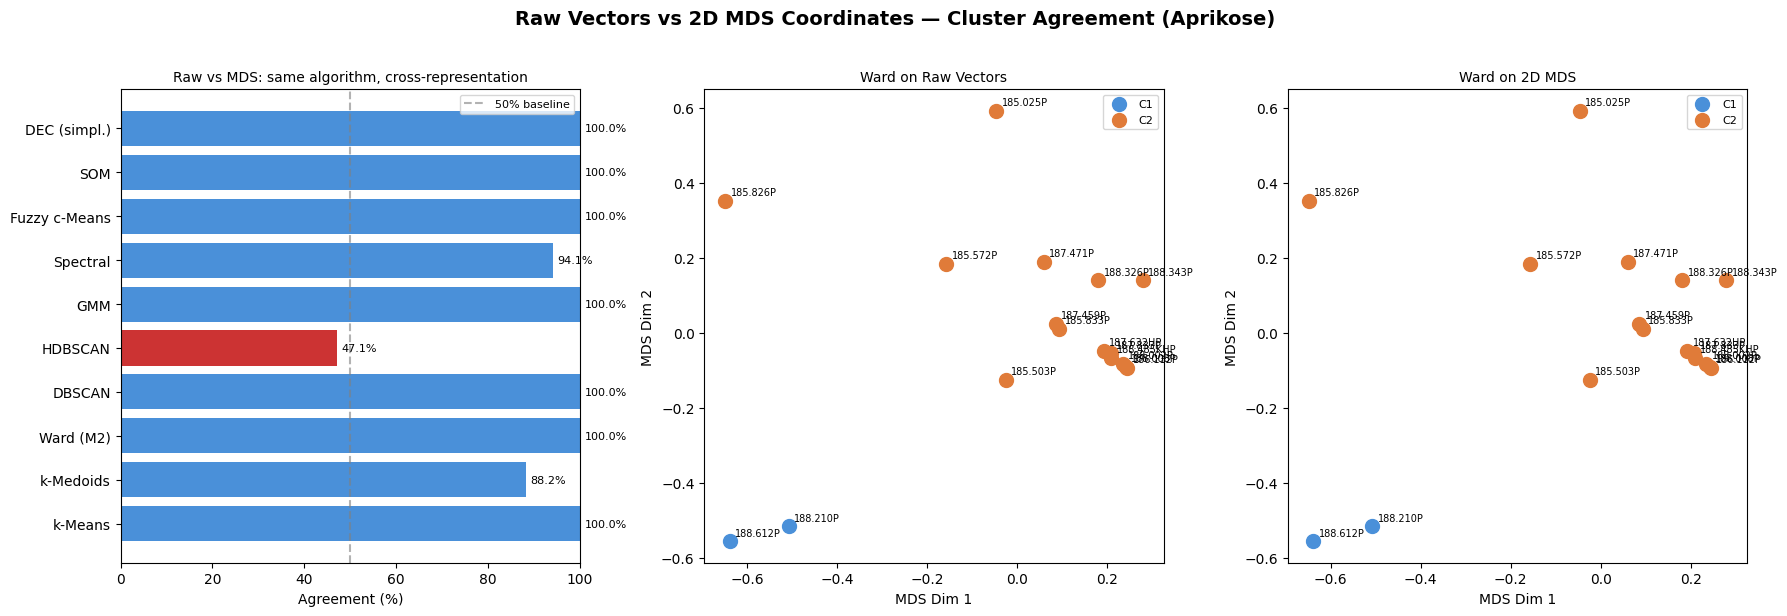

Saved: outputs/aprikose_raw_vs_mds_comparison.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib
from itertools import combinations

# Average pairwise agreement for a label dictionary
def mean_pairwise_agreement(lbl_dict, all_recipes):
    names_avail = [n for n, l in lbl_dict.items() if l is not None]
    pairs = list(combinations(names_avail, 2))
    if not pairs:
        return 0.0
    scores = []
    for a, b in pairs:
        scores.append(pairwise_agreement(lbl_dict[a], lbl_dict[b], all_recipes))
    return float(np.mean(scores))

mean_raw = mean_pairwise_agreement(algo_labels_dict, recipes)
mean_mds = mean_pairwise_agreement(algo_mds_labels,  recipes)

# Per-algorithm: agreement of that algorithm (raw) with its MDS counterpart
raw_vs_mds_rows = []
for name in algo_labels_dict:
    lbl_r = algo_labels_dict[name]
    lbl_m = algo_mds_labels[name]
    if lbl_r is None or lbl_m is None:
        cross = None
    else:
        cross = pairwise_agreement(lbl_r, lbl_m, recipes)
    raw_vs_mds_rows.append((name, cross))

print('Algorithm     | Raw vs MDS agreement')
print('-' * 40)
for name, v in raw_vs_mds_rows:
    print(f'{name:20s} | {"N/A" if v is None else f"{v:.1f}%"}')
print(f'\nMean pairwise agreement — Raw vectors: {mean_raw:.1f}%')
print(f'Mean pairwise agreement — MDS 2D:      {mean_mds:.1f}%')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Raw Vectors vs 2D MDS Coordinates — Cluster Agreement (Aprikose)',
             fontsize=14, fontweight='bold', y=1.02)

# Left: per-algorithm raw vs MDS cross-agreement
names_plot  = [r[0] for r in raw_vs_mds_rows if r[1] is not None]
values_plot = [r[1] for r in raw_vs_mds_rows if r[1] is not None]
colors_bar  = ['#4a90d9' if v >= 80 else '#e07b39' if v >= 60 else '#cc3333'
               for v in values_plot]
axes[0].barh(names_plot, values_plot, color=colors_bar)
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.6, label='50% baseline')
axes[0].set_xlabel('Agreement (%)')
axes[0].set_title('Raw vs MDS: same algorithm, cross-representation', fontsize=10)
axes[0].set_xlim(0, 100)
for i, v in enumerate(values_plot):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)
axes[0].legend(fontsize=8)

# Middle: MDS scatter colored by each algo (raw vs MDS side by side for Ward)
ward_raw = algo_labels_dict.get('Ward (M2)')
ward_mds = algo_mds_labels.get('Ward (M2)')
palette  = ['#4a90d9', '#e07b39', '#3ab57a', '#cc3333',
            '#9b59b6', '#f1c40f', '#1abc9c', '#e74c3c']

for ax, lbl, title in [(axes[1], ward_raw, 'Ward on Raw Vectors'),
                        (axes[2], ward_mds, 'Ward on 2D MDS')]:
    if lbl is None:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    uniq = sorted(set(lbl))
    for ci, c in enumerate(uniq):
        mask = np.array(lbl) == c
        xs = coords_m2[mask, 0]
        ys = coords_m2[mask, 1]
        ax.scatter(xs, ys, s=100, color=palette[ci % len(palette)],
                   label=f'C{c}', zorder=3)
        for j, r in enumerate(np.array(recipes)[mask]):
            ax.annotate(r, (xs[j], ys[j]), fontsize=7,
                        xytext=(4, 4), textcoords='offset points')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('MDS Dim 1')
    ax.set_ylabel('MDS Dim 2')

plt.tight_layout()
plt.savefig('../outputs/aprikose_raw_vs_mds_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/aprikose_raw_vs_mds_comparison.png')
